<a href="https://colab.research.google.com/github/lenmecc/miniature-enigma/blob/main/FoodImageClass_S10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PROYECTO**

**Ejemplificación de una Red CNN (Convolutional Neural Network) y Transfer Learning**


**Dataset**: Food_Data.zip Este archivo deberá copiarse al espacio de Google Drive, en esta dirección: /content/drive/MyDrive/

# **Contexto**
La clasificación de imágenes se ha vuelto menos complicada con el aprendizaje profundo y la disponibilidad de conjuntos de datos y recursos computacionales más grandes. La red neuronal convolucional es la técnica de clasificación de imágenes más popular y ampliamente utilizada en los últimos días.

Clicks es una empresa de fotografía de stock y es una fuente en línea de imágenes disponibles para que personas y empresas las descarguen. Fotógrafos de todo el mundo suben imágenes relacionadas con alimentos a la agencia de fotografía de stock todos los días. Dado que el volumen de imágenes que se suben diariamente es alto, será difícil para cualquier persona etiquetar las imágenes manualmente.

Clicks ha decidido usar solo tres categorías de alimentos (**Bread**, **Soup**, y  **Vegetables-Fruits**) por ahora, y tú, como científico de datos en Clicks, necesitas construir un modelo de clasificación usando un conjunto de datos que ayude a etiquetar las imágenes en diferentes categorías.

## **Conjunto de Datos**

La carpeta del conjunto de datos contiene diferentes imágenes de alimentos. Las imágenes ya están divididas en carpetas de Entrenamiento y Prueba.
Cada carpeta tiene cuatro subcarpetas llamadas **Bread**, **Soup**, y  **Vegetables-Fruits**. Estas carpetas contienen imágenes de las respectivas clases.

**Instrucciones** para acceder a los datos a través de Google Colab:

Sigue los siguientes pasos:

1) Descarga el archivo zip

2) Sube el archivo a tu unidad y descomprime la carpeta usando el código proporcionado en el cuaderno.

3) Monta tu Google Drive usando el código a continuación.

```
from google.colab import drive
drive.mount('/content/drive')
```

4) Ahora, puedes leer el conjunto de datos como se menciona en el código a continuación.





### Monta Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Usaremos visualkeras para mostrar la estructura de la Red
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.2 MB/s eta 0:00:00


### **Importando las librerías necesarias**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 # Este es un módulo importante que debe importarse y que puede incluso causar problemas al leer los datos si no se utiliza.
import seaborn as sns #  para visualización de datos
import tensorflow as tf
import keras
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten # importando las rutinas necesarias para los diferemtes tipos de capas
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Activation, Input, LeakyReLU,Activation
from tensorflow.keras import backend
from tensorflow.keras.utils import to_categorical #para realizar *one-hot encoding*
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import RMSprop,Adam,SGD # Métodos para optimizar el modelo
from tensorflow.keras.callbacks import EarlyStopping  #método de *regularization* para prevenir el *overfitting*
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import losses, optimizers
from google.colab.patches import cv2_imshow
import cv2
from tensorflow.keras.preprocessing import image

# Importando todos los submódulos requeridos de Keras
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

In [ ]:
!unzip "/content/drive/MyDrive/Food_Data.zip"

Archive:  /content/drive/MyDrive/Food_Data.zip
   creating: Food_Data/Testing/
   creating: Food_Data/Testing/Bread/
  inflating: Food_Data/Testing/Bread/0.jpg  
  inflating: Food_Data/Testing/Bread/1.jpg  
  inflating: Food_Data/Testing/Bread/10.jpg  
  inflating: Food_Data/Testing/Bread/100.jpg  
  inflating: Food_Data/Testing/Bread/101.jpg  
  inflating: Food_Data/Testing/Bread/102.jpg  
  inflating: Food_Data/Testing/Bread/103.jpg  
  inflating: Food_Data/Testing/Bread/104.jpg  
  inflating: Food_Data/Testing/Bread/105.jpg  
  inflating: Food_Data/Testing/Bread/106.jpg  
  inflating: Food_Data/Testing/Bread/107.jpg  
  inflating: Food_Data/Testing/Bread/108.jpg  
  inflating: Food_Data/Testing/Bread/109.jpg  
  inflating: Food_Data/Testing/Bread/11.jpg  
  inflating: Food_Data/Testing/Bread/110.jpg  
  inflating: Food_Data/Testing/Bread/111.jpg  
  inflating: Food_Data/Testing/Bread/112.jpg  
  inflating: Food_Data/Testing/Bread/113.jpg  
  inflating: Food_Data/Testing/Bread/114.jp

### **Leyendo los datos de entrenamiento**

In [ ]:
# Almacenando la ruta de entrenamiento en una variable llamada DATADIR, y almacenando las categorías/etiquetas únicas en una lista.

DATADIR = "/content/Food_Data/Training"                                        # Ruta de los datos de entrenamiento después de descomprimir.
CATEGORIES = ["Bread","Soup","Vegetable-Fruit"]                                # Almacenando todas las categorías en la variable categories
IMG_SIZE=150                                                                   # Definiendo el tamaño de la imagen a 150.

In [ ]:
# Aquí utilizaremos una función personalizada, create_training_data(), para extraer las imágenes del directorio.
training_data = []                                                             # Almacenando todas las imágenes de entrenamiento.
def create_training_data():
    for category in CATEGORIES:                                                # Iterando sobre cada categoría de la lista CATEGORIES.
        path = os.path.join(DATADIR,category)                                  # Uniendo imágenes con etiquetas.
        class_num = category
        for img in os.listdir(path):
          img_array = cv2.imread(os.path.join(path,img))                       # Leyendo los datos.
          new_array = cv2.resize(img_array,(IMG_SIZE,IMG_SIZE))                # Redimensionando las imágenes.
          training_data.append([new_array,class_num])                          # Añadiendo tanto las imágenes como las etiquetas.
create_training_data()

### **Leyendo los datos de testing**


In [ ]:
DATADIR_test = "/content/Food_Data/Testing"                                    # Ruta de los datos de entrenamiento después de descomprimir.
CATEGORIES =  ["Bread","Soup","Vegetable-Fruit"]                               # Almacenando todas las categorías en la variable categories
IMG_SIZE=150                                                                   # Definiendo el tamaño de la imagen a 150.

In [ ]:
# Aquí utilizaremos otra función personalizada, create_testing_data(), para extraer las imágenes del directorio.
testing_data = []                                                              # Almacenando todas las imágenes de entrenamiento.

def create_testing_data():
    for category in CATEGORIES:                                                # Iterando sobre cada categoría de la lista CATEGORIES.
        path = os.path.join(DATADIR_test,category)                             # Uniendo imágenes con etiquetas.
        class_num = category
        for img in os.listdir(path):
          img_array = cv2.imread(os.path.join(path,img))                       # Leyendo los datos.
          new_array = cv2.resize(img_array,(IMG_SIZE,IMG_SIZE))                # Redimensionando las imágenes.
          testing_data.append([new_array,class_num])                           # Añadiendo tanto las imágenes como las etiquetas.

create_testing_data()

**Visualizemos imágenes al azar de cada una de las cuatro clases..**




In [ ]:
# Creando 4 listas diferentes para almacenar los nombres de las imágenes de cada categoría, leyéndolos de sus respectivos directorios.
bread_imgs = [fn for fn in os.listdir(f'{DATADIR}/{CATEGORIES[0]}') ]          # Iterando sobre la ruta de cada imagen del directorio de Bread.
soup_imgs = [fn for fn in os.listdir(f'{DATADIR}/{CATEGORIES[1]}')]            # Iterando sobre la ruta de cada imagen del directorio de Soup.
veg_fruit_imgs = [fn for fn in os.listdir(f'{DATADIR}/{CATEGORIES[2]}') ]      # Iterando sobre la ruta de cada imagen del directorio de Vegetables-Fruits.



# Seleccionando aleatoriamente 3 imágenes de cada categoría.
select_bread = np.random.choice(bread_imgs, 3, replace = False)
select_soup = np.random.choice(soup_imgs, 3, replace = False)
select_veg_fruit = np.random.choice(veg_fruit_imgs, 3, replace = False)

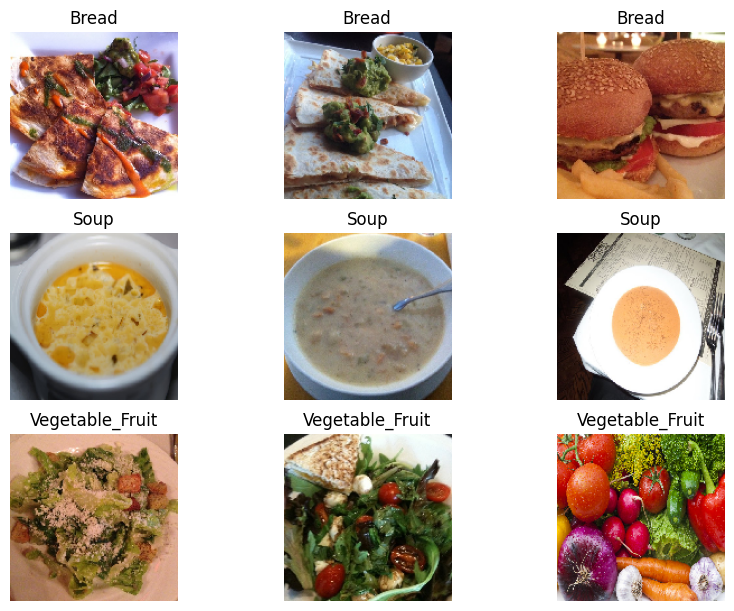

In [ ]:

# Trazando una matriz de imágenes de 4 x 3.
fig = plt.figure(figsize = (10,10))

# Trazando tres imágenes de cada una de las cuatro categorías iterando a través de sus rutas.
for i in range(9):
    if i < 3:
        fp = f'{DATADIR}/{CATEGORIES[0]}/{select_bread[i]}'                    # Aquí datadir es una ruta a los datos de entrenamiento y categories[1] indica la segunda etiqueta bread, y aquí estamos iterando para tomar las tres imágenes aleatorias que hemos almacenado en la variable select_x variable
        label = 'Bread'
    if i>=3 and i<6:
        fp = f'{DATADIR}/{CATEGORIES[1]}/{select_soup[i-3]}'                   # Aquí datadir es una ruta a los datos de entrenamiento y categories[1] indica la segunda etiqueta Soup, y aquí estamos iterando para tomar las tres imágenes aleatorias que hemos almacenado en la variable select_x variable
        label = 'Soup'
    if i>=6 and i<9:
        fp = f'{DATADIR}/{CATEGORIES[2]}/{select_veg_fruit[i-6]}'              # Aquí datadir es una ruta a los datos de entrenamiento y categories[2] indica la tercera etiqueta Vegetables-Fruits, y aquí estamos iterando para tomar las tres imágenes aleatorias que hemos almacenado en la variable select_no_t.
        label = 'Vegetable_Fruit'
    ax = fig.add_subplot(4, 3, i+1)

    # Mostrando cada imagen usando la función load_img
    fn = image.load_img(fp, target_size = (150,150))
    plt.imshow(fn, cmap='Greys_r')
    plt.title(label)
    plt.axis('off')
plt.show()

### **Pre-procesamiento de los datos**

In [ ]:
# Creando dos listas diferentes para almacenar los arreglos de Numpy y las etiquetas correspondientes.
X_train = []
y_train = []
np.random.shuffle(training_data)                                               # Aleatorizando los datos para reducir la varianza y asegurando que el modelo se mantenga general y se sobreajuste menos.
for features,label in training_data:                                           # Iterando sobre los datos de entrenamiento que se generan a partir de la función create_training_data().
    X_train.append(features)                                                   # Añadiendo imágenes a X_train.
    y_train.append(label)                                                      # Añadiendo etiquetas a y_train.

In [ ]:
# Creando dos listas diferentes para almacenar los arreglos de Numpy y las etiquetas correspondientes.
X_test = []
y_test = []

np.random.shuffle(testing_data)                                                # Aleatorizando los datos para reducir la varianza y asegurando que el modelo se mantenga general y se sobreajuste menos.
for features,label in testing_data:                                            # Iterando sobre los datos de entrenamiento que se generan a partir de la función create_testing_data().
    X_test.append(features)                                                    # Añadiendo imágenes a X_test.
    y_test.append(label)                                                       # Añadiendo etiquetas a y_test.

In [ ]:
# Convirtiendo las listas a dataframes
y_train = pd.DataFrame(y_train, columns=["Label"],dtype=object)
y_test = pd.DataFrame(y_test, columns=["Label"],dtype=object)

### **Análisis exploratorio**

In [ ]:
# Convirtiendo la lista en un *DataFrame*.
count=y_train.Label.value_counts()
print(count)
print('*'*10)
count=y_train.Label.value_counts(normalize=True)
print(count)

Label
Soup               1500
Bread               994
Vegetable-Fruit     709
Name: count, dtype: int64
**********
Label
Soup               0.468311
Bread              0.310334
Vegetable-Fruit    0.221355
Name: proportion, dtype: float64


In [ ]:
# Convirtiendo los valores de los píxeles en un arreglo de *Numpy*.
X_train= np.array(X_train)
X_test= np.array(X_test)

In [ ]:
X_train.shape

(3203, 150, 150, 3)

**NOTA**

Las imágenes están representadas digitalmente en forma de arreglos de *Numpy*, lo que se puede observar a partir de los valores generados en *X_train* anteriormente. Por lo tanto, es posible realizar todas las operaciones de preprocesamiento y construir nuestro modelo *CNN* utilizando directamente los arreglos de *Numpy*. Así, incluso si los datos se proporcionan en forma de arreglos de *Numpy* en lugar de imágenes, podemos usarlos para trabajar en nuestro modelo.



Dado que los datos proporcionados se almacenan en las variables *X_train*, *X_test*, *y_train* y *y_test*, no es necesario dividir los datos más.

**Normalizando los datos**

En redes neuronales, siempre se sugiere **normalizar las entradas de características**. La normalización tiene los siguientes beneficios durante el entrenamiento de un modelo de redes neuronales:

1. **La normalización hace que el entrenamiento sea más rápido y reduce las posibilidades de quedar atrapado en óptimos locales.**
2. En redes neuronales profundas, **la normalización ayuda a evitar problemas de gradientes explosivos.** El problema de los gradientes explosivos ocurre cuando se acumulan grandes gradientes de error y resultan en actualizaciones muy grandes de los pesos del modelo de red neuronal durante el entrenamiento. Esto hace que el modelo sea inestable y no pueda aprender de los datos de entrenamiento.

Como sabemos, los **valores de los píxeles de las imágenes varían de 0 a 255**, aquí simplemente estamos **dividiendo todos los valores de los píxeles por 255 para estandarizar todas las imágenes y tener valores entre 0 y 1.**

In [ ]:
## Normalizando los datos de las imágenes.
X_train= X_train/255.0

### **Encoding de la variable objetivo**

*Label Binarizer* es otra técnica utilizada para codificar las variables objetivo, la cual reduce la dispersión en comparación con el *one hot encoder*. Puedes consultar la documentación [aquí](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelBinarizer.html)

Por ejemplo:
Si tenemos 4 clases como **"Good"**, **"Better"**, **"Okay"**, **"Bad"**.
Después de aplicar *LabelBinarizer* a estas 4 clases, el resultado de la salida estará en forma de arreglo.
* [1, 1, 0, 0] --------- Good
* [0, 1, 0, 0] --------- Better
* [0, 0, 1, 0] --------- Okay
* [0, 0, 1, 1] --------- Bad

Cada clase será representada en forma de arreglo.



In [ ]:
from sklearn.preprocessing import LabelBinarizer
# Almacenando la función *LabelBinarizer* en la variable *lb*.
lb = LabelBinarizer()
# Aplicando *fit_transform* a la variable objetivo de entrenamiento.
y_train_e = lb.fit_transform(y_train)
# Aplicando solo *transform* a la variable objetivo de prueba.
y_test_e = lb.transform(y_test)

### **Construcción de los modelos CNN**

- **CNN** (Convolutional Neural Network)

#### **Convolutional Neural Network (CNN)**

**Modelo 1:**

In [ ]:
from tensorflow.keras import backend
backend.clear_session()
#Fijando la semilla para los generadores de números aleatorios para asegurar que obtengamos el mismo resultado cada vez.
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

* **Filters**: 256 - Número de filtros en la primera capa oculta. Esto también se llama **Kernel**.
* **Kernel_Size**: El tamaño del kernel se refiere aquí a la anchura x altura de la máscara del filtro. El *kernel_size* debe ser un número entero impar. Los valores típicos para *kernel_size* incluyen: (1, 1), (3, 3), (5, 5), (7, 7).
* **Padding**: El tipo de padding se llama *SAME* porque el tamaño de salida es el mismo que el tamaño de entrada (cuando *stride=1*). Usar *'SAME'* asegura que el filtro se aplique a todos los elementos de la entrada. Normalmente, el padding se establece en *"SAME"* durante el entrenamiento del modelo. El tamaño de salida es matemáticamente conveniente para cálculos adicionales.
* **MaxPool2D**: El max pooling es una operación de agrupamiento que calcula el valor máximo para parches de un mapa de características y lo usa para crear un mapa de características submuestreado (agrupado). Generalmente se usa después de una capa de convolución.
* **Flatten**: El *flattening* convierte los datos en un arreglo unidimensional para ingresarlos a la siguiente capa. Aplanamos la salida de las capas de convolución para crear un único vector de características largo. Y se conecta al modelo de clasificación final, que se llama capa completamente conectada.

In [ ]:
# Inicializando un modelo *sequential*.
model = Sequential()

# Añadiendo la primera capa de convolución con 64 filtros y un tamaño de kernel de 3x3, el padding 'same' proporciona el mismo tamaño de salida que el tamaño de entrada.
# Input_shape denota la dimensión de la imagen de entrada de las imágenes
model.add(Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(150,150,3)))
# Añadiendo *max pooling* para reducir el tamaño de la salida de la primera capa de convolución.
model.add(MaxPooling2D((2, 2), padding = 'same'))

model.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model.add(MaxPooling2D((2, 2), padding = 'same'))


model.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model.add(MaxPooling2D((2, 2), padding = 'same'))

# Aplanando la salida de la capa de convolución después de *max pooling* para prepararla para crear conexiones densas.
model.add(Flatten())

# Añadiendo una capa densa completamente conectada con 100 neuronas.
model.add(Dense(100, activation='relu'))

# Añadiendo la capa de salida con 10 neuronas y funciones de activación *softmax* ya que este es un problema de clasificación multiclase.
model.add(Dense(3, activation='softmax'))

# Utilizando el optimizador SGD
opt = SGD(learning_rate=0.01, momentum=0.9)

# Compilando el modelo
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Generando el resumen del modelo
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 11552)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     1,155,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185,107 (4.52 MB)

 Trainable params: 1,185,107 (4.52 MB)

 Non-trainable params: 0 (0.00 B)

1. Si el problema tiene tres clases para predecir, entonces los neuronas en la capa de salida serán 3.

**model.add(Dense(3, activation="softmax"))**

2. Si el problema tiene diez clases para predecir, entonces los neuronas en la capa de salida serán 10.

**model.add(Dense(10, activation="softmax"))**

Como podemos ver en el resumen anterior, este modelo CNN entrenará y aprenderá **1,185,107 parámetros (pesos y sesgos)**.

Ahora vamos a compilar y entrenar el modelo usando los datos de entrenamiento. Aquí, estamos utilizando la función de pérdida - categorical_crossentropy ya que este es un problema de clasificación multi-clase. Intentaremos minimizar esta pérdida en cada iteración usando el optimizador de nuestra elección. Además, estamos eligiendo la precisión (accuracy) como la métrica para medir el rendimiento del modelo.

In [ ]:
# Ajustando el modelo con 30 épocas y `validation_split` del 10%. - NO CORRER -
history=model.fit(X_train,
          y_train_e,
          epochs=30,
          batch_size=32,validation_split=0.10)

Epoch 1/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - accuracy: 0.4660 - loss: 1.0529 - val_accuracy: 0.4548 - val_loss: 1.0427
Epoch 2/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5285 - loss: 0.9636 - val_accuracy: 0.3832 - val_loss: 1.4865
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5517 - loss: 0.9271 - val_accuracy: 0.5327 - val_loss: 0.8831
Epoch 4/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6062 - loss: 0.7788 - val_accuracy: 0.5483 - val_loss: 0.9075
Epoch 5/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6437 - loss: 0.7373 - val_accuracy: 0.5794 - val_loss: 0.8630
Epoch 6/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6589 - loss: 0.6953 - val_accuracy: 0.6791 - val_loss: 0.7143
Epoch 7/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7311 - loss: 0.5948 - val_accuracy: 0.6106 - val_loss: 0.8183
Epoch 8/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7686 - loss: 0.5401 - val_accuracy: 0.7072 - 

**Graficando la curva de precisión versus época.**

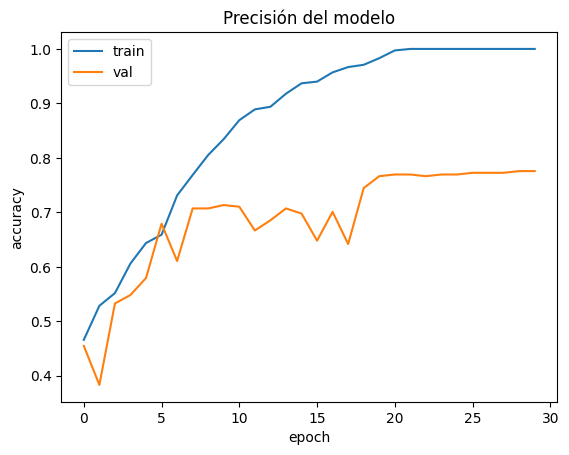

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Precisión del modelo')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Según el gráfico anterior, parece que el modelo está sobreajustando. Vamos a intentar usar Dropout en el próximo modelo.

In [ ]:
model.evaluate(X_test,(y_test_e))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6554 - loss: 416.1530


[416.1530456542969, 0.6553930640220642]

In [ ]:
# Predicción en Test
y_test_pred_ln = model.predict(X_test)
y_test_pred_classes_ln = np.argmax(y_test_pred_ln, axis=1)
normal_y_test = np.argmax(y_test_e, axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


Dado que hemos convertido la variable objetivo en un array NumPy usando `LabelBinarizer`, ahora estamos convirtiendo la variable objetivo a su forma original utilizando la función `numpy.argmax()`, la cual devuelve los índices del elemento máximo del array en un eje particular. Esta forma original de la variable objetivo se utilizará para calcular la precisión y graficar la matriz de confusión.

In [ ]:
# Accuracy en Test
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy_score((normal_y_test), y_test_pred_classes_ln)

0.6553930530164533

<Axes: >

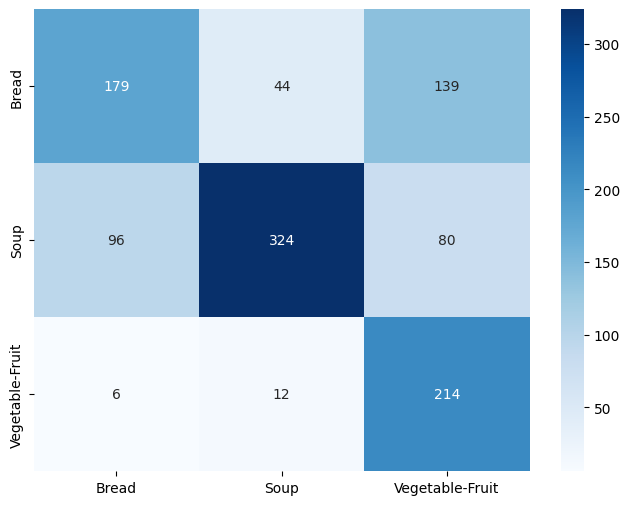

In [ ]:
cf_matrix = confusion_matrix(normal_y_test, y_test_pred_classes_ln)

# Matriz de confusión por valor verdadero de cada categoría.
plt.figure(figsize=(8,6))
sns.heatmap(cf_matrix, xticklabels=CATEGORIES, yticklabels=CATEGORIES, annot=True, fmt='d', cmap='Blues')

El modelo está alcanzando > 60% de precisión en los datos de prueba.

Visualizemos el modelo en forma estilizada

### Modelo 2:

Intentemos construir otro modelo CNN con más capas añadidas al modelo.

In [ ]:
# Reseteando el backend
from tensorflow.keras import backend
backend.clear_session()
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Inicializando un modelo secuencial.
model_3 = Sequential()
# Agregando la primera capa convolucional con 256 filtros, tamaño de kernel 5x5, activación ReLU y relleno 'same', proporciona un tamaño de salida igual al tamaño de entrada.
# `input_shape` denota las dimensiones de las imágenes de entrada.
model_3.add(Conv2D(filters = 256, kernel_size = (5,5),padding = 'Same',
                 activation ='relu', input_shape = (150,150,3)))
# Agregando Max Pooling para reducir el tamaño de la salida de la primera capa convolucional.
model_3.add(MaxPool2D(pool_size=(2,2)))

# Agregando la segunda capa convolucional con 128 filtros, tamaño de kernel 3x3 y función de activación ReLU.
model_3.add(Conv2D(filters = 128, kernel_size = (5,5),padding = 'Same',
                 activation ='relu'))
# adding max pooling to reduce the size of output of first conv layer
model_3.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
#  adding dropout to randomly switch off 25% neurons to reduce overfitting

# Agregando la tercera capa convolucional con 64 filtros, tamaño de kernel 3x3 y función de activación ReLU.
model_3.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same',
                 activation ='relu'))
# Agregando Max Pooling para reducir el tamaño de la salida de la primera capa convolucional.
model_3.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
#  Agregando Dropout para apagar aleatoriamente el 30% de las neuronas y reducir el sobreajuste.
model_3.add(Dropout(0.3))

# Agregando la cuarta capa convolucional con 32 filtros, tamaño de kernel 3x3 y función de activación ReLU.
model_3.add(Conv2D(filters = 32, kernel_size = (3,3),padding = 'Same',
                 activation ='relu'))
# Agregando Max Pooling para reducir el tamaño de la salida de la primera capa convolucional.
model_3.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
#  Agregando Dropout para apagar aleatoriamente el 30% de las neuronas y reducir el sobreajuste.
model_3.add(Dropout(0.3))

# Aplanando la salida tridimensional de la capa convolucional después del Max Pooling para prepararla para crear conexiones densas.
model_3.add(Flatten())
# Agregando la primera capa densa completamente conectada con 64 neuronas.
model_3.add(Dense(64, activation = "relu"))
#  Agregando Dropout para apagar aleatoriamente el 50% de las neuronas y reducir el overfitting
model_3.add(Dropout(0.5))
# Agregando la segunda capa densa completamente conectada con 32 neuronas.
model_3.add(Dense(32, activation = "relu"))
#  Agregando Dropout para apagar aleatoriamente el 50% de las neuronas y reducir el overfitting.
model_3.add(Dropout(0.5))

# Agregando la capa de salida con 4 neuronas y función de activación softmax, ya que este es un problema de clasificación multi-clase con 3 clases.
model_3.add(Dense(3, activation = "softmax"))

In [ ]:
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 256)  │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 128)    │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2592)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       165,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,099,171 (4.19 MB)

 Trainable params: 1,099,171 (4.19 MB)

 Non-trainable params: 0 (0.00 B)

Como podemos ver en el resumen anterior, este modelo CNN entrenará y aprenderá **1,099,171 parámetros (pesos y sesgos)**.

Ahora vamos a compilar y entrenar el modelo usando los datos de entrenamiento. Aquí, estamos utilizando la función de pérdida - categorical_crossentropy ya que este es un problema de clasificación multi-clase. Intentaremos minimizar esta pérdida en cada iteración usando el optimizador de nuestra elección. Además, estamos eligiendo la precisión (accuracy) como la métrica para medir el rendimiento del modelo.

In [ ]:
optimizer = Adam(learning_rate=0.001)
model_3.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])
history=model_3.fit(X_train,
          y_train_e,
          epochs=30,
          batch_size=32,validation_split=0.10)

Epoch 1/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 57s 369ms/step - accuracy: 0.4365 - loss: 1.0826 - val_accuracy: 0.4548 - val_loss: 1.0463
Epoch 2/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 19s 204ms/step - accuracy: 0.4646 - loss: 1.0669 - val_accuracy: 0.4548 - val_loss: 1.0587
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 21s 205ms/step - accuracy: 0.4795 - loss: 1.0231 - val_accuracy: 0.5452 - val_loss: 0.9442
Epoch 4/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 19s 206ms/step - accuracy: 0.5611 - loss: 0.8778 - val_accuracy: 0.5576 - val_loss: 0.8400
Epoch 5/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 19s 205ms/step - accuracy: 0.5999 - loss: 0.8122 - val_accuracy: 0.5826 - val_loss: 0.8198
Epoch 6/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 203ms/step - accuracy: 0.6131 - loss: 0.8099 - val_accuracy: 0.6075 - val_loss: 0.7486
Epoch 7/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 19s 205ms/step - accuracy: 0.6260 - loss: 0.7653 - val_accuracy: 0.6012 - val_loss: 0.7556
Epoch 8/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 19s 205ms/step - accuracy: 0.6280 - loss: 0.7426 - val_accu

**Graficando la curva de precisión (Accuracy) versus época.**

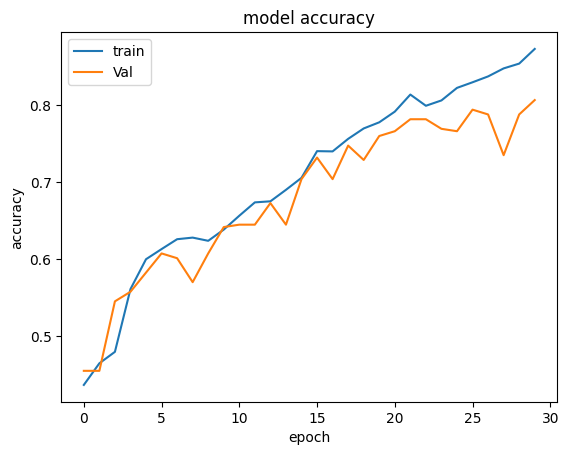

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'Val'], loc='upper left')
plt.show()

La precisión (accuracy) de entrenamiento y validación parece estar bien. Vamos a calcular la precisión en los datos de prueba.

In [ ]:
model_3.evaluate(X_test,y_test_e)

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.6106 - loss: 154.3773


[154.37734985351562, 0.6106032729148865]

Al comparar la precisión de entrenamiento y prueba, parece que el modelo no está sobreajustando en demasía, por lo que agregar más capas al modelo funcionó. Podemos decir que este modelo CNN es mejor que el anterior (aunque muestra un Accuracy bajo para test). También podemos intentar construir diferentes modelos aumentando las capas ocultas y ver si obtenemos una buena precisión.

In [ ]:
y_test_pred_ln3 = model_3.predict(X_test)
y_test_pred_classes_ln3 = np.argmax(y_test_pred_ln3, axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step


In [ ]:
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy_score(normal_y_test, y_test_pred_classes_ln3)

0.6106032906764168

<Axes: >

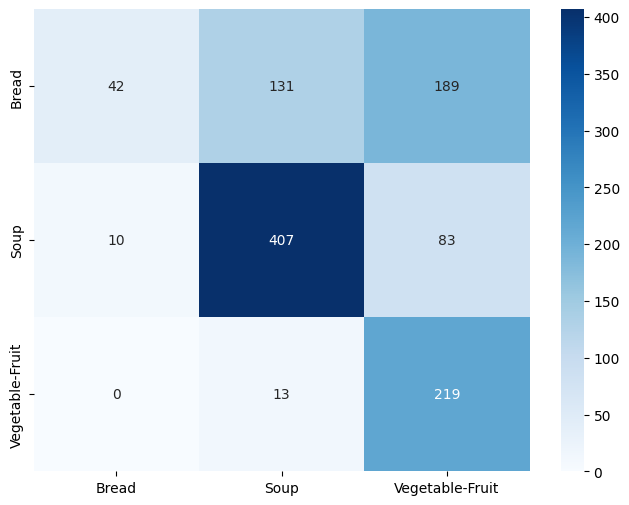

In [ ]:
cf_matrix = confusion_matrix(normal_y_test, y_test_pred_classes_ln3)

# Matriz de confusión para el modelo_3
plt.figure(figsize=(8,6))
sns.heatmap(cf_matrix, xticklabels=CATEGORIES, yticklabels=CATEGORIES, annot=True, fmt='d', cmap='Blues')
#sns.heatmap(cf_matrix_n1, xticklabels=CATEGORIES, yticklabels=CATEGORIES, annot=True)

**Informe de clasificación para cada clase**

- **Precisión:** la precisión es la fracción de instancias relevantes entre las instancias recuperadas.

- **Recuperación (Recall):** la recuperación es la fracción de instancias relevantes que fueron recuperadas.

- **F1 Score:** La puntuación F1 es la media armónica ponderada de precisión y recuperación, alcanzando su valor óptimo en 1 y su peor valor en 0. El parámetro beta determina el peso de la recuperación en la puntuación combinada.

**CNN Modelo 1 (llamado *model*)**

In [ ]:
from sklearn.metrics import classification_report
print(classification_report((normal_y_test), y_test_pred_classes_ln))

              precision    recall  f1-score   support

           0       0.64      0.49      0.56       362
           1       0.85      0.65      0.74       500
           2       0.49      0.92      0.64       232

    accuracy                           0.66      1094
   macro avg       0.66      0.69      0.65      1094
weighted avg       0.71      0.66      0.66      1094



**CNN Modelo 2 (llamado *model_3*)**

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(normal_y_test, y_test_pred_classes_ln3))

              precision    recall  f1-score   support

           0       0.81      0.12      0.20       362
           1       0.74      0.81      0.77       500
           2       0.45      0.94      0.61       232

    accuracy                           0.61      1094
   macro avg       0.66      0.62      0.53      1094
weighted avg       0.70      0.61      0.55      1094



### **Predicción**

Vamos a predecir usando el mejor modelo, que es `model_3`, graficando una imagen aleatoria de los datos `X_test` y ver si nuestro mejor modelo predice la imagen correctamente o no.

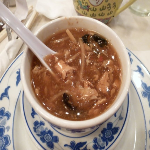

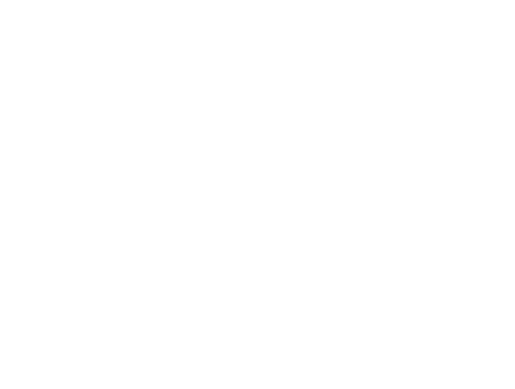

In [ ]:
# Mostrando la imagen de prueba
cv2_imshow(X_test[3])
plt.axis('off')
plt.show()


In [ ]:
# Prediciendo la imagen de prueba con el mejor modelo y almacenando el valor de predicción en la variable `res`.
res=model.predict(X_test[3].reshape(1,150,150,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


In [ ]:
# Aplicando `argmax` en la predicción para obtener el índice del valor más alto.
i=np.argmax(res)
if(i == 0):
    print("Bread")
if(i==1):
    print("Soup")
if(i==2):
    print("Vegetable-Fruit")

Vegetable-Fruit


### **Conclusión**

1. Como hemos visto, el modelo CNN - 2 (model_3) pudo predecir correctamente la imagen de prueba con una precisión de prueba por arriba del 50%.

2. **Todavía hay margen para mejorar la precisión de prueba del modelo CNN** elegido aquí. Se pueden utilizar diferentes arquitecturas y optimizadores para obtener un mejor clasificador de alimentos.

3. Se puede aplicar transfer learning al conjunto de datos para mejorar la precisión.



#**Transfer Learning (VGG16) with Data Agumentation**
###**Creación de un tercer modelo usando Transfer Learning**


#### **Data Augmentation**

En la mayoría de los estudios de casos en la vida real, generalmente es difícil recolectar muchas imágenes y luego entrenar CNNs. En ese caso, una idea de la que podemos aprovecharnos es la Data Augmentation (aumento de datos). Las CNN tienen la propiedad de **invarianza translacional**, es decir, pueden reconocer un objeto como un objeto, incluso cuando su apariencia varía de alguna manera translacional. Teniendo en cuenta esta propiedad, podemos aumentar las imágenes utilizando las siguientes técnicas:

1. **Horizontal Flip**: True/False
2. **Vertical Flip**: True/False
3. **Height Shift**: Valor entre 0 y 1
4. **Width Shift**: Valor entre 0 y 1
5. **Rotation**: Valor entre 0 y 180
6. **Shear**: Valor entre 0 y 1
7. **Zoom**: Valor entre 0 y 1

In [ ]:
# Guardando las rutas de los datos de entrenamiento y test
train_dir = "/content/Food_Data/Training"
test_dir  = "/content/Food_Data/Testing"

# Todas las imágenes deben ser reescaladas por 1/255.
train_datagen = ImageDataGenerator(rescale=1. / 255.0,
                              horizontal_flip = True,
                              vertical_flip = False,
                              height_shift_range= 0.1,
                              width_shift_range=0.1,
                              rotation_range=20,
                              shear_range = 0.1,
                              zoom_range=0.1)
test_datagen  = ImageDataGenerator(rescale = 1.0/255.)

# Considerando imágenes de entrenamiento en lotes de 20 usando el generador `train_datagen`.
train_generator = train_datagen.flow_from_directory(train_dir,
                                                    batch_size=20,
                                                    class_mode='categorical',
                                                    target_size=(150, 150))

test_generator =  test_datagen.flow_from_directory(test_dir,
                                                         batch_size=20,
                                                         class_mode  = 'categorical',
                                                         target_size = (150, 150))

Found 3203 images belonging to 3 classes.
Found 1094 images belonging to 3 classes.


- Ahora, vamos a construir un modelo utilizando la idea de **Transfer Learning** con Data Augmentation. Utilizaremos una arquitectura predefinida, **VGG16**, que fue entrenada en el conjunto de datos ImageNet y quedó en segundo lugar en la competencia ImageNet en 2014. A continuación se muestra un esquema del modelo VGG16.

- Para entrenar VGG16, utilizaremos directamente las capas convolucionales y de pooling y congelaremos sus pesos, es decir, no se realizará entrenamiento en ellas. Eliminaremos las capas completamente conectadas ya presentes y agregaremos nuestras propias capas completamente conectadas para esta tarea de clasificación binaria.

![vgg16](https://upload.wikimedia.org/wikipedia/commons/2/24/VGG16.png)

Las siguientes son las capas del modelo:

Capas Convolucionales = 13
Capas de Pooling = 5
Capas Densas = 3
Exploremos las capas en detalle:

Entrada: Imagen de dimensiones (224, 224, 3).
* **Capa Convolucional Conv1:**
Conv1-1: 64 filtros
Conv1-2: 64 filtros y Max Pooling
Dimensiones de la imagen: (224, 224)
* **Capa Convolucional Conv2:**
Ahora, aumentamos los filtros a 128
Dimensiones de la imagen de entrada: (112, 112)
Conv2-1: 128 filtros
Conv2-2: 128 filtros y Max Pooling

* **Capa Convolucional Conv3:**
Nuevamente, duplicamos los filtros a 256, y ahora añadimos otra capa convolucional
Dimensiones de la imagen de entrada: (56, 56)
Conv3-1: 256 filtros
Conv3-2: 256 filtros
Conv3-3: 256 filtros y Max Pooling

* **Capa Convolucional Conv4:**
Similar a Conv3, pero ahora con 512 filtros
Dimensiones de la imagen de entrada: (28, 28)
Conv4-1: 512 filtros
Conv4-2: 512 filtros
Conv4-3: 512 filtros y Max Pooling

* **Capa Convolucional Conv5:**
Igual que Conv4
Dimensiones de la imagen de entrada: (14, 14)
Conv5-1: 512 filtros
Conv5-2: 512 filtros
Conv5-3: 512 filtros y Max Pooling

Las dimensiones de salida aquí son (7, 7).
*
En este punto, aplanamos la salida de esta capa para generar un vector de características.*

* **Capa Densa FC1:** 4096 nodos, generando un vector de características de tamaño (1, 4096)

* **Capa Densa 2,  FC2:** 4096 nodos, generando un vector de características de tamaño (1, 4096)

* **Capa Densa 3,  FC3:** 4096 nodos, generando 1000 canales para 1000 clases.

* Esto luego se pasa a una función de activación Softmax

**Capa de salida**

In [ ]:
# Cargando el modelo VGG16
model = VGG16(weights='imagenet')
# Resumen del modelo en su totalidad
model.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Obteniendo solo las capas convolucionales para transfer learning.
transfer_layer = model.get_layer('block5_pool')
vgg_model = Model(inputs=model.input, outputs=transfer_layer.output)

In [ ]:
vgg_model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Para eliminar las capas completamente conectadas del modelo pre-entrenado importado desde Keras, podemos especificar un argumento adicional que es **include_top**.

- **Si especificamos include_top = False, entonces el modelo se importará sin las capas completamente conectadas.** En este caso, no necesitaremos realizar los pasos anteriores de obtener la última capa convolucional y crear un modelo separado.

- Si especificamos include_top = False, también debemos especificar la forma de nuestra imagen de entrada.

- Keras tiene este argumento de palabra clave porque generalmente, al importar un modelo CNN pre-entrenado, no necesitamos las capas completamente conectadas y entrenamos nuestras propias capas completamente conectadas para nuestra tarea.

In [ ]:
vgg_model = VGG16(weights='imagenet', include_top = False, input_shape = (150,150,3))
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Haciendo todas las capas del modelo VGG no entrenables, es decir, congelándolas.
for layer in vgg_model.layers:
    layer.trainable = False

In [ ]:
for layer in vgg_model.layers:
    print(layer.name, layer.trainable)

input_layer_2 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 False
block5_conv2 False
block5_conv3 False
block5_pool False


In [ ]:
# Reseteando el backend
backend.clear_session()
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Inicializando el nuemo modelo (new_model) usando las capas del VGG16 model como transferencia
new_model = Sequential()

# Agregando la parte convolucional del modelo VGG16 anteriormente mencionado.
new_model.add(vgg_model)

# Aplanando la salida del modelo VGG16 porque proviene de una capa convolucional.
new_model.add(Flatten())

# Agregando una capa densa de entrada 32 neuronas
new_model.add(Dense(32, activation='relu'))
# Añadiendo DropOut de 20%
new_model.add(Dropout(0.2))
# Añadiendo una segunda capa densa de 32 neuronas
new_model.add(Dense(32, activation='relu'))
# Añadiendo la capa de salida
new_model.add(Dense(3, activation='softmax'))

In [ ]:
# Compilando el modelo
new_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Resumen del modelo
new_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       262,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,978,019 (57.14 MB)

 Trainable params: 263,331 (1.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
## Obteniendo un bloque grande único de datos de validación aleatorios para realizar pruebas después de cada época.
testX, testY = next(test_generator)

**Early stopping** es una técnica similar a la validación cruzada donde una parte de los datos de entrenamiento se mantiene como datos de validación. Cuando el rendimiento de los datos de validación comienza a empeorar, el modelo detendrá inmediatamente el entrenamiento.
- **Monitor**: Cantidad a monitorear.
- **Mode**: Uno de {"auto", "min", "max"}. En modo "min", el entrenamiento se detendrá cuando la cantidad monitoreada haya dejado de disminuir; en modo "max", se detendrá cuando la cantidad monitoreada haya dejado de aumentar; en modo "auto", la dirección se infiere automáticamente del nombre de la cantidad monitoreada.
- **Patience**: Número de épocas sin mejora después del cual se detendrá el entrenamiento.

El callback **ModelCheckpoint** se utiliza junto con el entrenamiento usando `model.fit()` para guardar un modelo o pesos (en un archivo de checkpoint) a intervalos determinados, de modo que el modelo o los pesos se puedan cargar más tarde para continuar el entrenamiento desde el estado guardado.

In [ ]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

## Ajustando el modelo VGG.
new_model_history = new_model.fit(train_generator,
                                  validation_data = (testX, testY),
                                  epochs=30,callbacks=[es, mc])

Epoch 1/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.7816 - loss: 0.5404
Epoch 1: val_accuracy improved from None to 1.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
161/161 ━━━━━━━━━━━━━━━━━━━━ 44s 219ms/step - accuracy: 0.8423 - loss: 0.4120 - val_accuracy: 1.0000 - val_loss: 0.1541
Epoch 2/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.8855 - loss: 0.3061
Epoch 2: val_accuracy did not improve from 1.00000
161/161 ━━━━━━━━━━━━━━━━━━━━ 30s 187ms/step - accuracy: 0.8951 - loss: 0.2857 - val_accuracy: 1.0000 - val_loss: 0.0537
Epoch 3/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9191 - loss: 0.2256
Epoch 3: val_accuracy did not improve from 1.00000
161/161 ━━━━━━━━━━━━━━━━━━━━ 30s 185ms/step - accuracy: 0.9157 - loss: 0.2349 - val_accuracy: 1.0000 - val_loss: 0.0381
Epoch 4/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9397 - loss: 0.1797
Epoch 4: val_accuracy did not improve from 1.00000
161/161 ━━━━━━━━━━━━━━━━━━━━ 30s 186ms/step - accuracy: 0.9269 - loss: 0.2048 - val_accuracy: 1.0000 - val_loss: 0.0445
Epoch 5/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step 

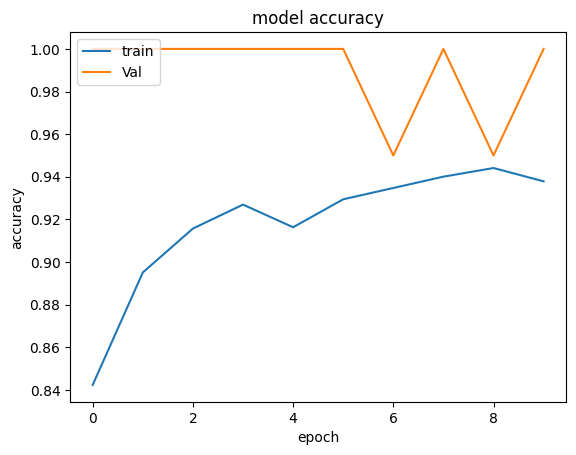

In [ ]:
plt.plot(new_model_history.history['accuracy'])
plt.plot(new_model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'Val'], loc='upper left')
plt.show()

In [ ]:
# Evaluando en el test set
new_model.evaluate(test_generator)

55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 217ms/step - accuracy: 0.9388 - loss: 0.2030


[0.20299986004829407, 0.9387568831443787]

In [ ]:
y_test_pred_ln4 = new_model.predict(X_test)
y_test_pred_classes_ln4 = np.argmax(y_test_pred_ln4, axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 212ms/step


In [ ]:
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy_score(normal_y_test, y_test_pred_classes_ln4)

0.850091407678245

<Axes: >

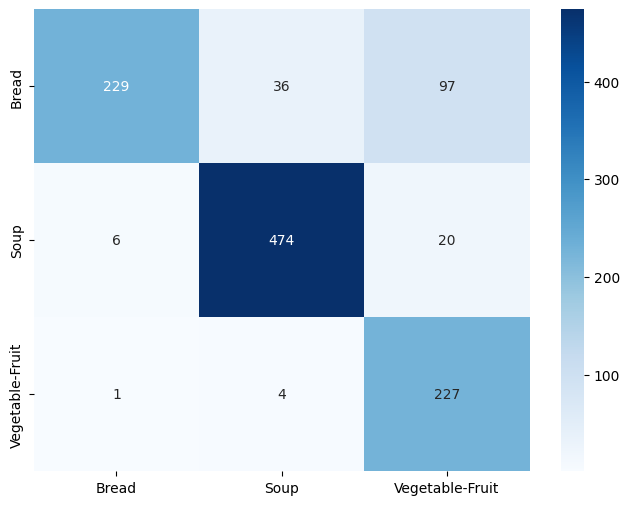

In [ ]:
cf_matrix = confusion_matrix(normal_y_test, y_test_pred_classes_ln4)

# Matriz de confusión para el "new_model"
plt.figure(figsize=(8,6))
sns.heatmap(cf_matrix, xticklabels=CATEGORIES, yticklabels=CATEGORIES, annot=True, fmt='d', cmap='Blues')

In [ ]:
# Reporte de clasificación para new_model
from sklearn.metrics import classification_report
print(classification_report((normal_y_test), y_test_pred_classes_ln4))

              precision    recall  f1-score   support

           0       0.97      0.63      0.77       362
           1       0.92      0.95      0.93       500
           2       0.66      0.98      0.79       232

    accuracy                           0.85      1094
   macro avg       0.85      0.85      0.83      1094
weighted avg       0.88      0.85      0.85      1094



### **Predicción**

Let us predict using the best model which is model_3 by plotting one random image from X_test data with variable and see if our best model is predicting the image correctly or not.

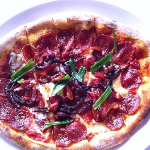

In [ ]:
# Plotting the test image
cv2_imshow(X_test[10])

In [ ]:
# Prediciendo la imagen de prueba con el mejor modelo y almacenando el valor de predicción en la variable `res`.
res=new_model.predict(X_test[10].reshape(1,150,150,3))
# Aplicando `argmax` en la predicción para obtener el índice del valor más alto.
i=np.argmax(res)
if(i == 0):
    print("Bread")
if(i==1):
    print("Soup")
if(i==2):
    print("Vegetable-Fruit")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Bread


Intenta mostrar diferentes imágenes de los datos de prueba y verifica si el modelo está prediciendo la imagen correctamente.

1. Como hemos visto, el modelo CNN-3 (new_model) pudo predecir correctamente la imagen de prueba con una precisión ~ 80%.

2. **Todavía podría haber margen para mejorar la precisión del modelo CNN** elegido aquí. Intenta agregar una capa más densa al modelo VGG16 y verifica si puedes obtener una precisión mayor que la del mejor modelo.


### **FINAL DEL NOTEBOOK**